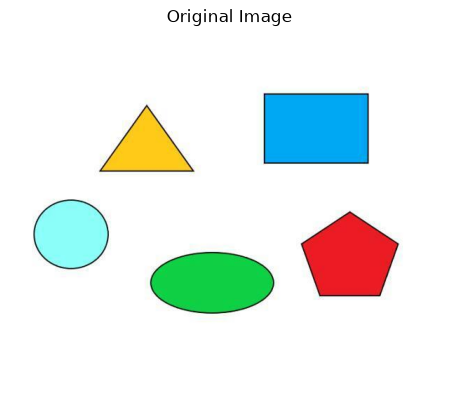

In [2]:
import cv2
import matplotlib.pyplot as plt

# قراءة الصورة
image = cv2.imread(
    r"C:\Users\PC-LAB1\Desktop\New folder\WhatsApp Image 2026-09-22 at 9.04.15 AM (1).jpeg"
)

# تحويل من BGR إلى RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# عرض الصورة
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

Object ID: 1
Area: 12375.0
Perimeter: 539.7300094366074
Bounding Box:
X = 199 Y = 315
Width = 178 Height = 90
Centroid:
CX = 287 CY = 359
Aspect Ratio: 1.9777777777777779
-----------------------------
Object ID: 2
Area: 11893.5
Perimeter: 541.2274830341339
Bounding Box:
X = 414 Y = 257
Width = 142 Height = 124
Centroid:
CX = 484 CY = 324
Aspect Ratio: 1.1451612903225807
-----------------------------
Object ID: 3
Area: 8461.5
Perimeter: 417.68837904930115
Bounding Box:
X = 33 Y = 241
Width = 108 Height = 101
Centroid:
CX = 86 CY = 290
Aspect Ratio: 1.0693069306930694
-----------------------------
Object ID: 4
Area: 6660.0
Perimeter: 489.52899742126465
Bounding Box:
X = 126 Y = 105
Width = 138 Height = 98
Centroid:
CX = 194 CY = 168
Aspect Ratio: 1.4081632653061225
-----------------------------
Object ID: 5
Area: 15009.5
Perimeter: 516.0416301488876
Bounding Box:
X = 360 Y = 88
Width = 152 Height = 104
Centroid:
CX = 435 CY = 139
Aspect Ratio: 1.4615384615384615
-------------------------

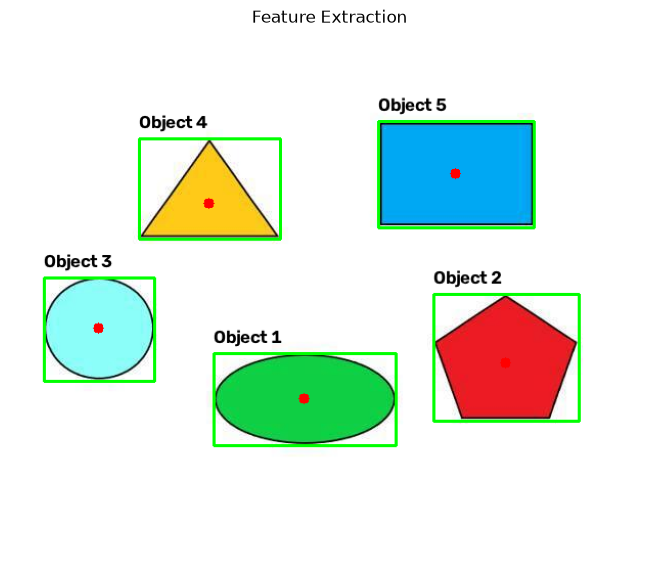

In [4]:
import cv2
import matplotlib.pyplot as plt

# قراءة الصورة
image = cv2.imread(
    r"C:\Users\PC-LAB1\Desktop\New folder\WhatsApp Image 2026-09-22 at 9.04.15 AM (1).jpeg"
)

# تحويل إلى Gray
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Threshold
_, binary = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

# استخراج Contours
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# نسخ الصورة للرسم
result = image.copy()

# رقم الجسم
object_id = 1

# المرور على جميع الأجسام
for contour in contours:

    # حساب المساحة
    area = cv2.contourArea(contour)

    # تجاهل الأجسام الصغيرة
    if area < 500:
        continue

    # حساب المحيط
    perimeter = cv2.arcLength(contour, True)

    # Bounding Box
    x, y, w, h = cv2.boundingRect(contour)

    # حساب Centroid
    M = cv2.moments(contour)

    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx = 0
        cy = 0

    # Aspect Ratio
    aspect_ratio = w / h if h != 0 else 0

    # رسم Bounding Box
    cv2.rectangle(
        result,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    # رسم Centroid
    cv2.circle(
        result,
        (cx, cy),
        5,
        (0, 0, 255),
        -1
    )

    # كتابة رقم الجسم
    cv2.putText(
        result,
        f"Object {object_id}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 0),
        2
    )

    # طباعة الخصائص
    print("Object ID:", object_id)
    print("Area:", area)
    print("Perimeter:", perimeter)
    print("Bounding Box:")
    print("X =", x, "Y =", y)
    print("Width =", w, "Height =", h)
    print("Centroid:")
    print("CX =", cx, "CY =", cy)
    print("Aspect Ratio:", aspect_ratio)
    print("-----------------------------")

    object_id += 1


# تحويل BGR إلى RGB
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# عرض النتيجة باستخدام plt
plt.figure(figsize=(10, 7))
plt.imshow(result_rgb)
plt.title("Feature Extraction")
plt.axis("off")
plt.show()

Mean BGR:
Blue : 233.49249032258064
Green: 238.1426853889943
Red  : 229.47703377609108

Intensity Features:
Mean Intensity: 235.02565464895636
Standard Deviation: 48.5734956571885


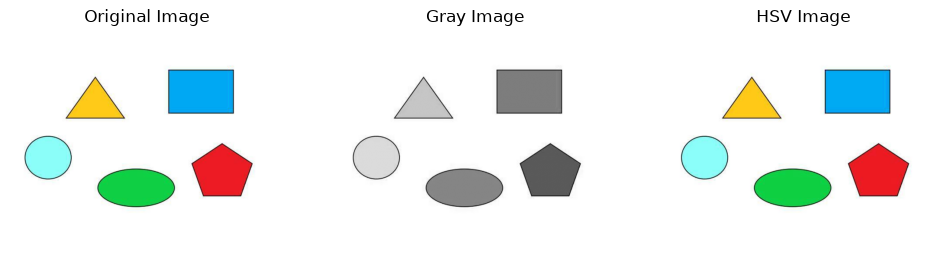

In [5]:
import cv2
import matplotlib.pyplot as plt

# قراءة الصورة
image = cv2.imread(
    r"C:\Users\PC-LAB1\Desktop\New folder\WhatsApp Image 2026-09-22 at 9.04.15 AM (1).jpeg"
)

# --------------------------------
# 1 - Mean BGR
# --------------------------------

mean_bgr = cv2.mean(image)[:3]

print("Mean BGR:")
print("Blue :", mean_bgr[0])
print("Green:", mean_bgr[1])
print("Red  :", mean_bgr[2])


# --------------------------------
# 2 - تحويل إلى Gray
# --------------------------------

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Mean Intensity
mean_intensity = gray.mean()

# Standard Deviation
std_intensity = gray.std()

print("\nIntensity Features:")
print("Mean Intensity:", mean_intensity)
print("Standard Deviation:", std_intensity)


# --------------------------------
# 3 - تحويل إلى HSV
# --------------------------------

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)


# --------------------------------
# 4 - عرض الصور
# --------------------------------

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
hsv_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Gray Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hsv_rgb)
plt.title("HSV Image")
plt.axis("off")

plt.show()

Mean BGR:
Blue : 233.49249032258064
Green: 238.1426853889943
Red  : 229.47703377609108

Intensity Features:
Mean Intensity: 235.02565464895636
Standard Deviation: 48.5734956571885


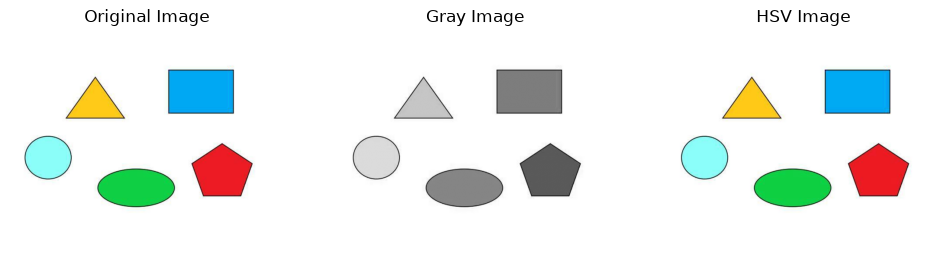


IoU Result:
IoU = 0.391304347826087


In [7]:
import cv2
import matplotlib.pyplot as plt


# ==========================================
# 1 - قراءة الصورة
# ==========================================

image = cv2.imread(
    r"C:\Users\PC-LAB1\Desktop\New folder\WhatsApp Image 2026-09-22 at 9.04.15 AM (1).jpeg"
)


# ==========================================
# 2 - Mean BGR
# ==========================================

mean_bgr = cv2.mean(image)[:3]

print("Mean BGR:")
print("Blue :", mean_bgr[0])
print("Green:", mean_bgr[1])
print("Red  :", mean_bgr[2])


# ==========================================
# 3 - تحويل إلى Gray
# ==========================================

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

mean_intensity = gray.mean()
std_intensity = gray.std()

print("\nIntensity Features:")
print("Mean Intensity:", mean_intensity)
print("Standard Deviation:", std_intensity)


# ==========================================
# 4 - تحويل إلى HSV
# ==========================================

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)


# ==========================================
# 5 - عرض الصور
# ==========================================

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
hsv_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Gray Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hsv_rgb)
plt.title("HSV Image")
plt.axis("off")

plt.show()


# ==========================================
# 6 - IoU Function
# ==========================================

def iou(box_a, box_b):

    # إحداثيات المستطيل الأول
    ax1, ay1, ax2, ay2 = box_a

    # إحداثيات المستطيل الثاني
    bx1, by1, bx2, by2 = box_b

    # منطقة التقاطع
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)

    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    # عرض وارتفاع التقاطع
    inter_w = max(0, ix2 - ix1)
    inter_h = max(0, iy2 - iy1)

    # مساحة التقاطع
    intersection = inter_w * inter_h

    # مساحة المستطيل الأول
    area_a = (ax2 - ax1) * (ay2 - ay1)

    # مساحة المستطيل الثاني
    area_b = (bx2 - bx1) * (by2 - by1)

    # مساحة الاتحاد
    union = area_a + area_b - intersection

    # حساب IoU
    if union != 0:
        return intersection / union
    else:
        return 0.0


# ==========================================
# 7 - تجربة IoU
# ==========================================

box1 = (100, 100, 300, 300)

box2 = (150, 150, 350, 350)

result = iou(box1, box2)

print("\nIoU Result:")
print("IoU =", result)